In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
from catboost import CatBoostClassifier, CatBoostRegressor
from scipy.stats import weibull_min
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import optimize
from scipy.special import gammaln

In [2]:
DATA_DIR = Path("../data/CMAPSSData")
IMG_DIR = Path("../images")
IMG_DIR.mkdir(exist_ok=True)

COLS = ["unit", "cycle"] + [f"op_{i}" for i in range(1, 4)] + [f"s_{i}" for i in range(1, 22)]
ALL_SENSORS = [f"s_{i}" for i in range(1, 22)]
WINDOW = 15
RUL_CAP = 125
N_EARLY = 30
RNG = np.random.default_rng(0)

In [3]:
def load(ds):
    tr = pd.read_csv(DATA_DIR / f"train_{ds}.txt", sep=r"\s+", header=None, names=COLS, engine="python")
    te = pd.read_csv(DATA_DIR / f"test_{ds}.txt", sep=r"\s+", header=None, names=COLS, engine="python")
    rul = pd.read_csv(DATA_DIR / f"RUL_{ds}.txt", header=None, names=["RUL"]).squeeze("columns").values
    return tr, te, rul
 
 
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1).sum()
 
 
def metrics(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "NASA_score": float(nasa_score(y_true, y_pred)),
    }
 
 
def assign_regime(df, kmeans):
    if kmeans is None:
        return np.zeros(len(df), dtype=int)
    return kmeans.predict(df[["op_1", "op_2", "op_3"]].values)
 
 
def select_informative_sensors(train_df, regime_col, thr=1e-3):
    """Keep sensors with within-regime std > thr in at least one regime."""
    kept = []
    for s in ALL_SENSORS:
        within = train_df.groupby(regime_col)[s].std().fillna(0)
        if within.max() > thr:
            kept.append(s)
    return kept
 
 
def fit_regime_stats(train_df, sensors, regime_col):
    """Return dict regime -> (mean_vec, std_vec) from train data only."""
    stats = {}
    for r, g in train_df.groupby(regime_col):
        mu = g[sensors].mean().values
        sd = g[sensors].std().replace(0, 1).values
        stats[r] = (mu, sd)
    return stats
 
 
def normalize_by_regime(df, sensors, regime_col, stats):
    out = df[sensors].values.astype(float).copy()
    r = df[regime_col].values
    for reg, (mu, sd) in stats.items():
        mask = r == reg
        if mask.any():
            out[mask] = (out[mask] - mu) / sd
    return pd.DataFrame(out, columns=[f"{s}_n" for s in sensors], index=df.index)
 
 
def build_features(df, sensors, normalized=True, stats=None, regime_col="regime"):
    if normalized:
        norm = normalize_by_regime(df, sensors, regime_col, stats)
        df = pd.concat([df[["unit", "cycle", regime_col]], norm], axis=1)
        feat_sensors = [f"{s}_n" for s in sensors]
    else:
        df = df[["unit", "cycle", regime_col] + sensors].copy()
        feat_sensors = sensors
 
    g = df.groupby("unit")[feat_sensors]
    roll = g.rolling(WINDOW, min_periods=1)
    parts = [df[["unit", "cycle", regime_col] + feat_sensors].reset_index(drop=True)]
    parts.append(roll.mean().reset_index(level=0, drop=True).add_suffix("_m").reset_index(drop=True))
    parts.append(roll.std().fillna(0).reset_index(level=0, drop=True).add_suffix("_sd").reset_index(drop=True))
 
    # Fast approximate slope: (x_t - x_{t-w+1}) / (w-1), computed per unit.
    # Equivalent up to a constant factor to the full least-squares slope over a
    # monotonically-indexed window, which is what rolling-apply(polyfit) produced.
    shifted = df.groupby("unit")[feat_sensors].shift(WINDOW - 1)
    sl = ((df[feat_sensors] - shifted) / (WINDOW - 1)).fillna(0).add_suffix("_sl").reset_index(drop=True)
    parts.append(sl)
    return pd.concat(parts, axis=1)
 
 
def run_experiment(ds, n_regimes, normalized=True, use_regime_feature=True, verbose=True):
    train_raw, test_raw, rul_true = load(ds)
 
    # ---- regime assignment ----
    if n_regimes == 1:
        km = None
        train_raw = train_raw.assign(regime=0)
        test_raw = test_raw.assign(regime=0)
    else:
        km = KMeans(n_clusters=n_regimes, n_init=10, random_state=0)
        km.fit(train_raw[["op_1", "op_2", "op_3"]].values)
        train_raw = train_raw.assign(regime=km.labels_)
        test_raw = test_raw.assign(regime=assign_regime(test_raw, km))
 
    sensors = select_informative_sensors(train_raw, "regime")
    if verbose:
        print(f"  [{ds}] {n_regimes} regime(s), {len(sensors)} informative sensors")
 
    stats = fit_regime_stats(train_raw, sensors, "regime") if normalized else None
    X_tr_df = build_features(train_raw, sensors, normalized=normalized, stats=stats)
    X_tr_df["RUL"] = (train_raw.groupby("unit").cycle.transform("max") - train_raw.cycle).clip(upper=RUL_CAP).values
 
    exclude = ["unit", "cycle", "RUL"]
    cat_features_arg = ["regime"]
    if not use_regime_feature:
        exclude.append("regime")
        cat_features_arg = None
    feature_cols = [c for c in X_tr_df.columns if c not in exclude]
 
    # 20%-of-units held-out val
    all_units = X_tr_df["unit"].unique()
    val_u = RNG.choice(all_units, size=max(20, len(all_units) // 5), replace=False)
    is_val = X_tr_df["unit"].isin(val_u).values
 
    X_tr_df["regime"] = X_tr_df["regime"].astype(int)
    X_tr = X_tr_df.loc[~is_val, feature_cols]
    y_tr = X_tr_df.loc[~is_val, "RUL"].values
    X_val = X_tr_df.loc[is_val, feature_cols]
    y_val = X_tr_df.loc[is_val, "RUL"].values
 
    model = CatBoostRegressor(
        iterations=1000, learning_rate=0.08, depth=5,
        loss_function="RMSE", eval_metric="RMSE",
        early_stopping_rounds=40, random_seed=42, verbose=False,
        cat_features=cat_features_arg,
    )
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val))
 
    # Official test set: last observation per unit
    X_te_df = build_features(test_raw, sensors, normalized=normalized, stats=stats)
    X_te_df["regime"] = X_te_df["regime"].astype(int)
    last = X_te_df.groupby("unit").tail(1).sort_values("unit")
    X_te = last[feature_cols]
    preds = np.clip(model.predict(X_te), 0, None)
 
    return {
        "model": model,
        "metrics": metrics(rul_true, preds),
        "preds": preds,
        "y_true": rul_true,
        "n_features": len(feature_cols),
        "n_sensors": len(sensors),
        "feature_cols": feature_cols,
        "best_iter": model.get_best_iteration(),
    }

In [4]:
def weibull_pdf(t, beta, eta):
    return (beta / eta) * (t / eta) ** (beta - 1) * np.exp(-(t / eta) ** beta)
 
def em_weibull_mixture(x, K=2, n_iter=200, tol=1e-6, seed=0):
    rng = np.random.default_rng(seed)
    n = len(x)
    # Init by splitting at median
    med = np.median(x)
    init_mask = x < med
    betas = np.array([3.0, 3.0])
    etas = np.array([np.mean(x[init_mask]) / np.exp(gammaln(1 + 1/3)),
                     np.mean(x[~init_mask]) / np.exp(gammaln(1 + 1/3))])
    pis = np.array([init_mask.mean(), 1 - init_mask.mean()])
 
    prev_ll = -np.inf
    for it in range(n_iter):
        # E step
        comp = np.stack([pis[k] * weibull_pdf(x, betas[k], etas[k]) for k in range(K)], axis=1)
        comp = np.clip(comp, 1e-300, None)
        gamma = comp / comp.sum(axis=1, keepdims=True)
 
        # M step: per component, weighted Weibull MLE via numerical root
        new_betas = np.zeros(K)
        new_etas = np.zeros(K)
        new_pis = gamma.mean(axis=0)
        for k in range(K):
            w = gamma[:, k]
            ws = w.sum()
            def score(b):
                xb = x ** b
                top = (w * xb * np.log(x)).sum()
                bot = (w * xb).sum()
                return top / bot - (w * np.log(x)).sum() / ws - 1 / b
            try:
                b_new = optimize.brentq(score, 0.3, 30.0)
            except ValueError:
                b_new = betas[k]
            eta_new = ((w * x ** b_new).sum() / ws) ** (1 / b_new)
            new_betas[k] = b_new
            new_etas[k] = eta_new
 
        betas, etas, pis = new_betas, new_etas, new_pis
        ll = np.log(np.stack([pis[k] * weibull_pdf(x, betas[k], etas[k])
                              for k in range(K)], axis=1).sum(axis=1)).sum()
        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll
 
    # Sort components by eta for reproducibility
    order = np.argsort(etas)
    return {"beta": betas[order], "eta": etas[order], "pi": pis[order],
            "logL": ll, "n_iter": it + 1, "gamma": gamma[:, order]}

In [5]:
def build_early_features(train_df, sensors, stats, n_early):
    """Per-unit: mean, std, slope of each normalized sensor over first n_early cycles."""
    rows = []
    for u, g in train_df.groupby("unit"):
        early = g.head(n_early)
        norm = normalize_by_regime(early, sensors, "regime", stats)
        row = {"unit": u}
        for s in sensors:
            col = norm[f"{s}_n"].values
            row[f"{s}_mean"] = col.mean()
            row[f"{s}_std"] = col.std() if len(col) > 1 else 0.0
            if len(col) >= 2:
                row[f"{s}_slope"] = np.polyfit(np.arange(len(col)), col, 1)[0]
            else:
                row[f"{s}_slope"] = 0.0
        rows.append(row)
    return pd.DataFrame(rows).set_index("unit")


In [6]:
train = load("FD004")[0]
 
# Regime clustering
km = KMeans(n_clusters=6, n_init=10, random_state=0).fit(
    train[["op_1", "op_2", "op_3"]].values)
train = train.assign(regime=km.labels_)
sensors = select_informative_sensors(train, "regime")
stats = fit_regime_stats(train, sensors, "regime")
 
# Weibull mixture → labels
lives = train.groupby("unit").cycle.max()
mix = em_weibull_mixture(lives.values.astype(float), K=2, n_iter=200)
p1 = mix["pi"][0] * weibull_min.pdf(lives.values, mix["beta"][0], 0, mix["eta"][0])
p2 = mix["pi"][1] * weibull_min.pdf(lives.values, mix["beta"][1], 0, mix["eta"][1])
labels = (p1 > p2).astype(int)  # 1 = short-life
print(f"FD004 train: {labels.sum()} short-life  |  {len(labels) - labels.sum()} long-life")

FD004 train: 82 short-life  |  167 long-life


In [7]:
# Features from first N_EARLY cycles
print(f"Building features from first {N_EARLY} cycles per unit...")
feat = build_early_features(train, sensors, stats, N_EARLY)
feat_cols = [c for c in feat.columns]
y = pd.Series(labels, index=lives.index).loc[feat.index].values
 
print(f"Feature matrix: {feat.shape}, class balance: {y.mean():.2%} short-life")

Building features from first 30 cycles per unit...
Feature matrix: (249, 51), class balance: 32.93% short-life


In [8]:
# ---- Logistic regression CV ----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
logit_proba = cross_val_predict(
    LogisticRegression(max_iter=2000, C=1.0),
    feat.values, y, cv=cv, method="predict_proba")[:, 1]
logit_pred = (logit_proba > 0.5).astype(int)
logit_auc = roc_auc_score(y, logit_proba)
logit_acc = accuracy_score(y, logit_pred)
 

In [9]:
# ---- CatBoost CV ----
cb_proba = cross_val_predict(
    CatBoostClassifier(iterations=300, depth=4, learning_rate=0.05,
                       verbose=False, random_seed=42),
    feat.values, y, cv=cv, method="predict_proba")[:, 1]
cb_pred = (cb_proba > 0.5).astype(int)
cb_auc = roc_auc_score(y, cb_proba)
cb_acc = accuracy_score(y, cb_pred)
 
print("\n" + "=" * 70)
print("EARLY-CYCLE MODE PREDICTION — 5-fold CV on FD004 train units")
print("=" * 70)
print(f"  Chance baseline (majority class)  accuracy = {max(y.mean(), 1 - y.mean()):.3f}")
print(f"  Logistic regression   AUC = {logit_auc:.3f}   acc = {logit_acc:.3f}")
print(f"  CatBoost classifier   AUC = {cb_auc:.3f}   acc = {cb_acc:.3f}")


EARLY-CYCLE MODE PREDICTION — 5-fold CV on FD004 train units
  Chance baseline (majority class)  accuracy = 0.671
  Logistic regression   AUC = 0.661   acc = 0.647
  CatBoost classifier   AUC = 0.654   acc = 0.663


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
print("\nLogistic regression detailed:")
print(classification_report(y, logit_pred, target_names=["long-life", "short-life"], digits=3))
print("Confusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(y, logit_pred),
                   index=["true_long", "true_short"],
                   columns=["pred_long", "pred_short"]))


Logistic regression detailed:
              precision    recall  f1-score   support

   long-life      0.701     0.826     0.758       167
  short-life      0.442     0.280     0.343        82

    accuracy                          0.647       249
   macro avg      0.571     0.553     0.551       249
weighted avg      0.615     0.647     0.622       249

Confusion matrix (rows=true, cols=pred):
            pred_long  pred_short
true_long         138          29
true_short         59          23


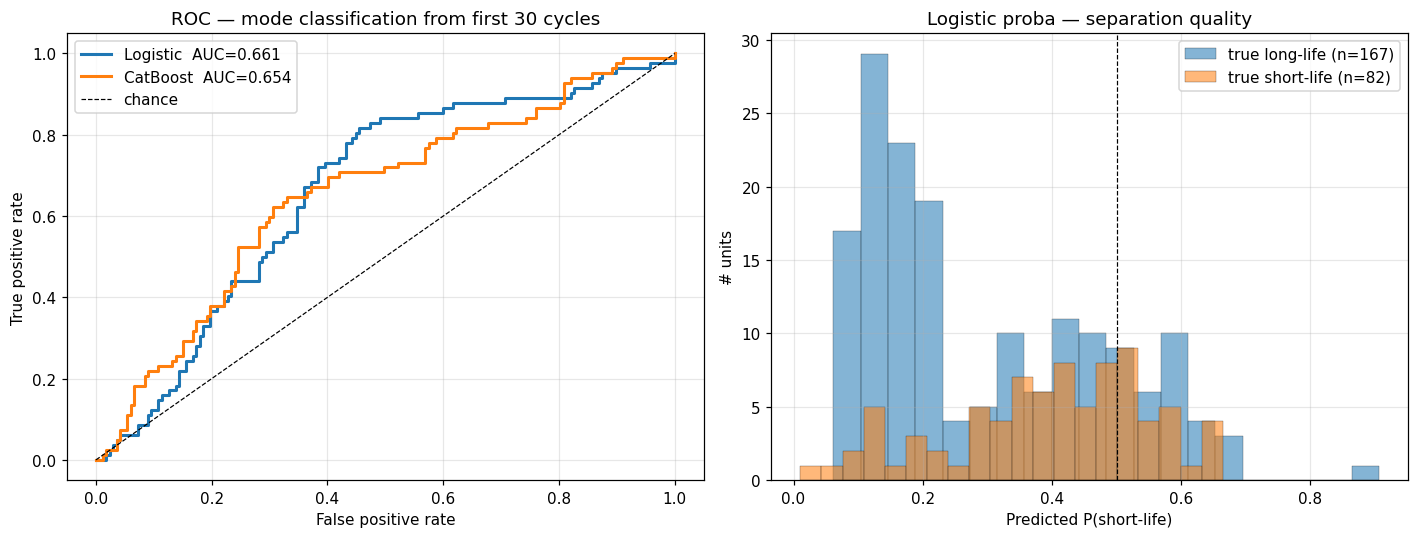

In [11]:
# ---- Plot ----
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
ax = axes[0]
fpr_l, tpr_l, _ = roc_curve(y, logit_proba)
fpr_c, tpr_c, _ = roc_curve(y, cb_proba)
ax.plot(fpr_l, tpr_l, lw=2, label=f"Logistic  AUC={logit_auc:.3f}")
ax.plot(fpr_c, tpr_c, lw=2, label=f"CatBoost  AUC={cb_auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC — mode classification from first {N_EARLY} cycles")
ax.legend()
ax.grid(alpha=0.3)
 
ax = axes[1]
for lbl, c, name in [(0, "tab:blue", "long-life"), (1, "tab:orange", "short-life")]:
    mask = y == lbl
    ax.hist(logit_proba[mask], bins=20, alpha=0.55, color=c,
            label=f"true {name} (n={mask.sum()})", edgecolor="black", lw=0.3)
ax.axvline(0.5, color="black", ls="--", lw=0.8)
ax.set_xlabel("Predicted P(short-life)")
ax.set_ylabel("# units")
ax.set_title("Logistic proba — separation quality")
ax.legend()
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(IMG_DIR / "70_early_mode_roc.png", bbox_inches="tight")
plt.show()
plt.close()

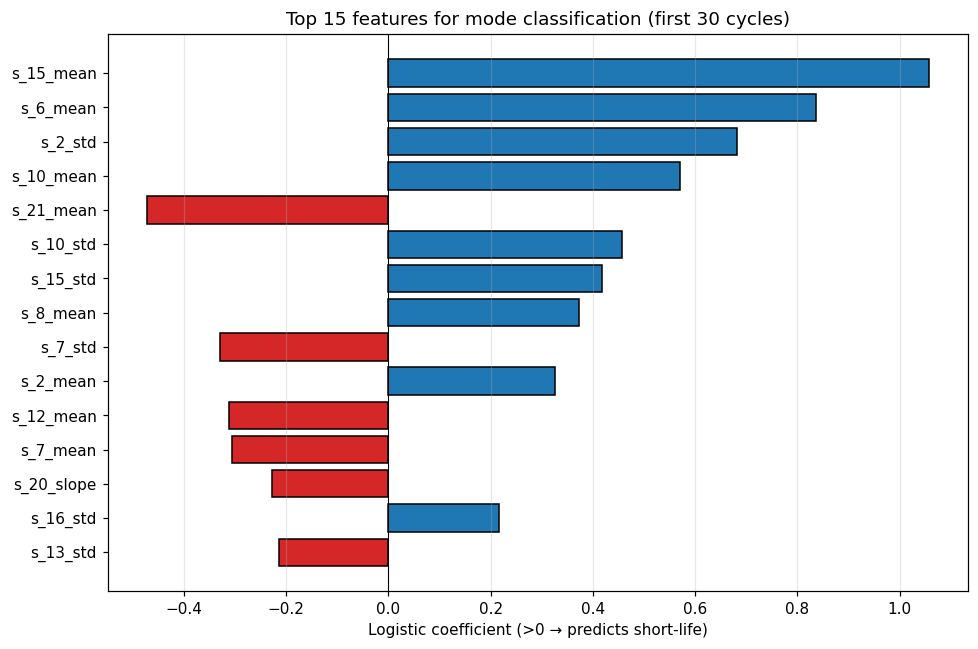

In [12]:
# Feature importance from logistic on full data
logit_full = LogisticRegression(max_iter=2000, C=1.0).fit(feat.values, y)
coef = pd.Series(logit_full.coef_[0], index=feat_cols)
top = coef.abs().sort_values(ascending=False).head(15)
 
fig, ax = plt.subplots(figsize=(9, 6))
vals = coef[top.index]
colors = ["tab:red" if v < 0 else "tab:blue" for v in vals.values]
ax.barh(vals.index[::-1], vals.values[::-1], color=colors[::-1], edgecolor="black")
ax.axvline(0, color="black", lw=0.7)
ax.set_xlabel("Logistic coefficient (>0 → predicts short-life)")
ax.set_title(f"Top 15 features for mode classification (first {N_EARLY} cycles)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(IMG_DIR / "71_mode_feature_importance.png", bbox_inches="tight")
plt.show()
plt.close()

In [13]:
# Save results
pd.DataFrame([{
    "model": "Logistic", "AUC": round(logit_auc, 3), "acc": round(logit_acc, 3),
    "N_EARLY": N_EARLY, "n_units": len(y),
}, {
    "model": "CatBoost", "AUC": round(cb_auc, 3), "acc": round(cb_acc, 3),
    "N_EARLY": N_EARLY, "n_units": len(y),
}]).to_csv("early_mode.csv", index=False)